# Pulse Shaping Methods

Quantum devices can be programmed by specifying a sequence of pulses. The pulse shaping configuration part (the `pulse_shaping` field of `SolverConfig`) defines how the pulse parameters are constructed.

In this notebook, we show how to use different pulse shaping methods.

Here, the two available pulse shaping methods are shown:

- `ADIABATIC` *(Has no parameters to be customized).*
- `OPTIMIZED` *(Has three parameters that can be customized).*

We choose the method when defining the configurations, with `pulse_shaping_method = PulseType.(method)`

##### Default config parameters:
- use_quantum: bool | None = False (*for using the pulse shaping methods, we have to set it to `True`.*)
- backend: str | BackendType = BackendType.QUTIP (possibly can be replace by `BackendType.EMU_MPS` or any value in `BackendType`)
- device: str | DeviceType | None = DeviceType.DIGITAL_ANALOG_DEVICE (also available: `ANALOG_DEVICE`)
- embedding_method: str | EmbedderType | None = EmbedderType.GREEDY (also available: `BLADE`)
- pulse_shaping_method: str | PulseType | None = PulseType.ADIABATIC (also available: `OPTIMIZED`) 

##### OPTIMIZED pulse shaping parameters:

- re_execute_opt_pulse: bool = False (`True`) *Whether we take the last pulse and make another optimization round following the pipeline (execute) or just take the results of the last one*
- optimized_n_calls: *Number of optimization rounds; default is 20 and minimum is 12.*
- optimized_initial_omega_parameters: [5.0, 10.0, 5.0,] *List with initial values for Amplitude (5.0, 10, 5.0) when using Optimized Pulse*
- optimized_initial_detuning_parameters: [-10.0, 0.0, 10.0] *List with initial values for Detuning (-10.0, 0.0, 10.0) when using Optimized Pulse*

In [ ]:
import torch

from qubosolver.qubo_instance import QUBOInstance
from qubosolver.config import SolverConfig, PulseShapingConfig
from qubosolver.qubo_types import PulseType
from qubosolver.solver import QuboSolver

import matplotlib.pyplot as plt
plt.rcParams["animation.html"] = "jshtml"

%matplotlib inline

#### Load the instance as a `QUBOInstance` object 

Here, we have a 3x3 QUBO matrix with negative diagonal and positive off-diagonal terms.

In [ ]:
coefficients = torch.tensor([[-1.0, 0.5, 0.2], [0.5, -2.0, 0.3], [0.2, 0.3, -3.0]])
instance = QUBOInstance(coefficients)

## Standard Adiabatic

Default method


In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.ADIABATIC),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 0.]]), costs=tensor([-3., -2., -1.,  0.]), counts=tensor([126,  57,  22, 295], dtype=torch.int32), probabilities=tensor([0.2520, 0.1140, 0.0440, 0.5900]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


If needed, one can access the pulse used and draw the sequence of pulses used by the quantum solver as follows:  

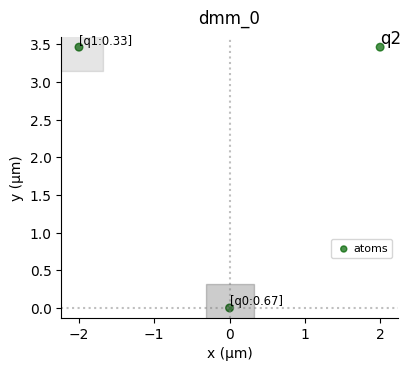

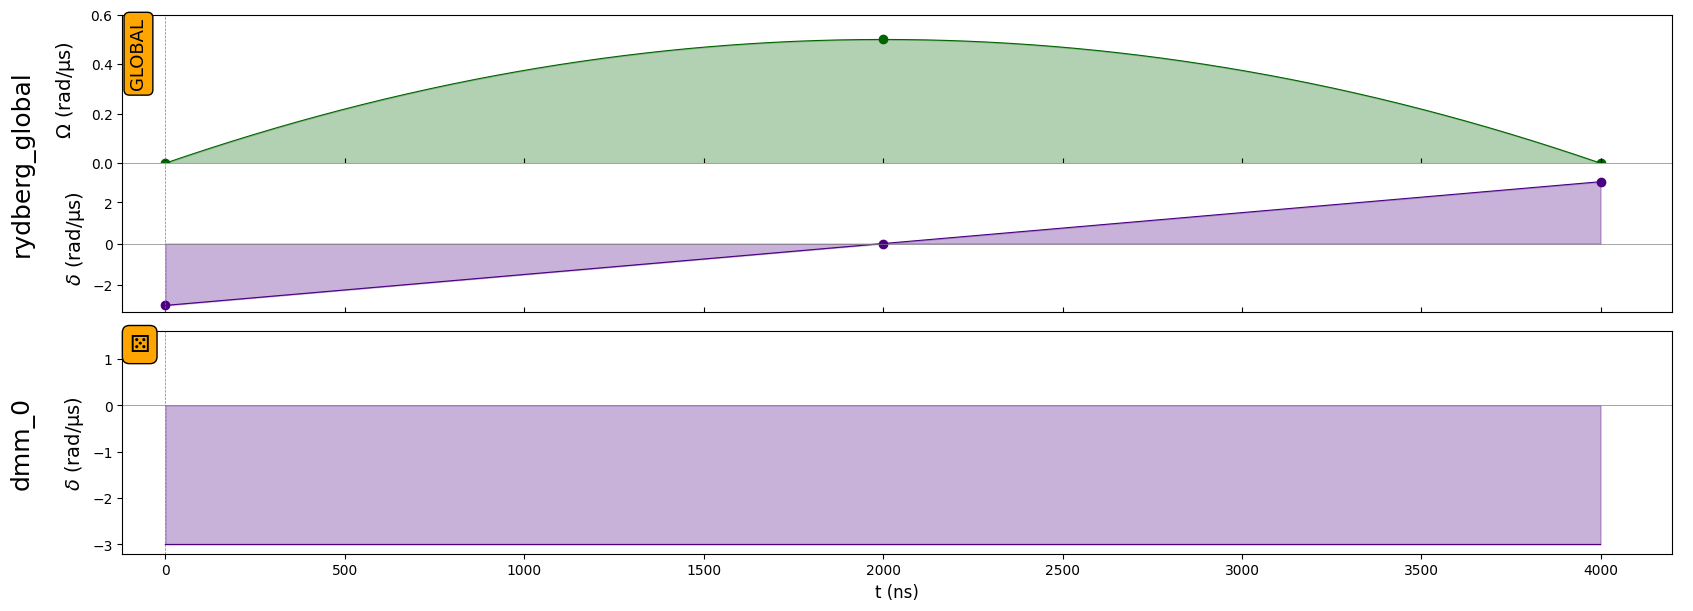

In [ ]:
embedding = solver.embedding()
pulse = solver.pulse(embedding)[0]
solver.draw_sequence(pulse, embedding)

## Optimized Pulse shaping 

#### Parameters to customize:

For the OPTIMIZED pulse shaping, we have the following parameters:
- n_calls
- re_execute_opt_pulse
- optimized_initial_omega_parameters
- optimized_initial_detuning_parameters

#### Default configuration

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.OPTIMIZED),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 0.]]), costs=tensor([-3., -2., -1.,  0.]), counts=tensor([15, 26, 15, 44], dtype=torch.int32), probabilities=tensor([0.1500, 0.2600, 0.1500, 0.4400]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing optimized_n_calls

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.OPTIMIZED), optimized_n_calls=13
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 0.]]), costs=tensor([-3., -2., -1.,  0.]), counts=tensor([11, 14, 17, 58], dtype=torch.int32), probabilities=tensor([0.1100, 0.1400, 0.1700, 0.5800]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing optimized_initial_omega_parameters and optimized_initial_detuning_parameters

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.OPTIMIZED, optimized_initial_omega_parameters=[2.0, 15.0, 5.0,], optimized_initial_detuning_parameters=[-45.0, 0.0, 25.0]),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 0.]]), costs=tensor([-3., -2., -1.,  0.]), counts=tensor([19, 18,  8, 55], dtype=torch.int32), probabilities=tensor([0.1900, 0.1800, 0.0800, 0.5500]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Changing re_execute_opt_pulse to True

In [ ]:
default_config = SolverConfig.from_kwargs(
    use_quantum=True, pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.OPTIMIZED, re_execute_opt_pulse=True),
)
solver = QuboSolver(instance, default_config)

solution = solver.solve()
print(solution)

QUBOSolution(bitstrings=tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 0.]]), costs=tensor([-3., -2., -1.,  0.]), counts=tensor([ 70,  63,  69, 298], dtype=torch.int32), probabilities=tensor([0.1400, 0.1260, 0.1380, 0.5960]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


#### Adding custom functions

One can change the pulse shaping method by incorporating custom functions for:
- Evaluating a candidate bitstring and QUBO via `optimized_custom_qubo_cost`
- Performing optimization with a different objective than the best cost via `optimized_custom_objective`
- Adding callback functions via `optimized_callback_objective`.

In [ ]:
from qubosolver.utils.qubo_eval import calculate_qubo_cost

# example of penalization
def penalized_qubo(bitstring: str, QUBO: torch.Tensor) -> float:
    return calculate_qubo_cost(bitstring, QUBO) + 2 * bitstring.count("0")

# example of saving intermediate results
opt_results = list()
def callback(d: dict) -> None:
    opt_results.append(d)

# example of using an average cost
def average_ojective(
    bitstrings: list,
    counts: list,
    probabilities: list,
    costs: list,
    best_cost: float,
    best_bitstring: str,
) -> float:
    return sum([p * c for p, c in zip(probabilities, costs)])

pulse_shaping=PulseShapingConfig(pulse_shaping_method=PulseType.OPTIMIZED, 
    re_execute_opt_pulse=True, 
    optimized_custom_qubo_cost=penalized_qubo, 
    optimized_callback_objective=callback,
    optimized_custom_objective = average_ojective,
)

config = SolverConfig(
    use_quantum=True, 
    pulse_shaping=pulse_shaping,
)

In [ ]:
solver = QuboSolver(instance, config)
solution = solver.solve()
len(opt_results), opt_results[-1]

(20,
 {'x': [2.486471395075838,
   7.858052023200356,
   5.138217059157475,
   -10.684578122317447,
   -68.62201818996644,
   76.75285499360697],
  'cost_eval': 2.23})

In [ ]:
solution

QUBOSolution(bitstrings=tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 0.]]), costs=tensor([-3., -2., -1.,  0.]), counts=tensor([171, 194, 124,  11], dtype=torch.int32), probabilities=tensor([0.3420, 0.3880, 0.2480, 0.0220]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)